# **Hybrid Retrieval on Unstructured Approach**

In [1]:
%pip install "unstructured[all-docs]"

Note: you may need to restart the kernel to use updated packages.


e:\The Leo Programmer\Internships\NRSC\Assignments\testing-models\.venv\Scripts\python.exe: No module named pip


In [2]:
# Warning control
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Loading Necessary Modules of Unstructured Library

from unstructured.chunking.title import chunk_by_title
from unstructured.partition.md import partition_md
from unstructured.partition.pdf import partition_pdf
from unstructured.staging.base import dict_to_elements

In [4]:
import unstructured.partition

help(unstructured.partition)

Help on package unstructured.partition in unstructured:

NAME
    unstructured.partition

PACKAGE CONTENTS
    api
    auto
    common (package)
    csv
    doc
    docx
    email
    epub
    html (package)
    image
    json
    md
    model_init
    msg
    ndjson
    odt
    org
    pdf
    pdf_image (package)
    ppt
    pptx
    rst
    rtf
    strategies
    text
    text_type
    tsv
    utils (package)
    xlsx
    xml

FILE
    e:\the leo programmer\internships\nrsc\assignments\testing-models\.venv\lib\site-packages\unstructured\partition\__init__.py




## **Data Ingestion Layer**

- Data ingestion layer is responsible for converting raw documents into structured, semantically meaningful, and traceable chunks that can be reliably used by retrieval and generation systems.

- Data ingestion includes document loading, parsing, cleaning, chunking, and metadata enrichment — and ends before embeddings are created.

In [5]:
# PDF Files Path

from pathlib import Path

pdf_dir = Path("../data/pdfs")
pdf_files = list(pdf_dir.glob("*.pdf"))
pdf_files

[WindowsPath('../data/pdfs/allafs.pdf'),
 WindowsPath('../data/pdfs/alldg.pdf'),
 WindowsPath('../data/pdfs/allrec.pdf'),
 WindowsPath('../data/pdfs/allsbe.pdf'),
 WindowsPath('../data/pdfs/bh1.pdf'),
 WindowsPath('../data/pdfs/budget_at_a_glance.pdf'),
 WindowsPath('../data/pdfs/Budget_Speech.pdf'),
 WindowsPath('../data/pdfs/Finance_Bill.pdf'),
 WindowsPath('../data/pdfs/frbm1.pdf'),
 WindowsPath('../data/pdfs/memo.pdf'),
 WindowsPath('../data/pdfs/OutcomeBudgetE2025_2026.pdf'),
 WindowsPath('../data/pdfs/Spotlight _ National Portal of India.pdf'),
 WindowsPath('../data/pdfs/vol1.pdf')]

In [6]:
# PDF Files Loading and Partitioning - Extract images, tables, and chunk text

from unstructured.partition.pdf import partition_pdf

all_elements = []

for pdf_path in pdf_files:
    elements = partition_pdf(
        filename=str(pdf_path),
        extract_images_in_pdf=False,
        #strategy = "hi_res",
        strategy = "fast",
        hi_res_model_name="yolox",
        infer_table_structure=True,
        chunking_strategy="by_title",
        max_characters=3000,
        #new_after_n_chars=3800,
        combine_text_under_n_chars=200,
        #extract_image_block_output_dir=path,
    )

    # Attach source metadata manually (VERY IMPORTANT)
    for el in elements:
        el.metadata.source = pdf_path.name

    all_elements.extend(elements)

Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-stroke color because expected 4 components but got [0]
Cannot set non-strok

Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because No

In [12]:
all_elements[:][1045].to_dict()

{'type': 'CompositeElement',
 'element_id': '6028ac4350da05cbe90070543b6dfd21',
 'text': 'ंजीगत\n\nCapital Outlay on Forestry and Wild Life\n\n4406\n\n33.91\n\n19.40\n\nसहका(cid:303)रता पर पू\n\nंजीगत प(cid:303)र(cid:681)य\n\nCapital Outlay on Co-operation\n\n4425\n\n...\n\n0.01\n\nवृहत और म(cid:559)म िसंचाई पर पू प(cid:303)र(cid:681)य',
 'metadata': {'file_directory': '..\\data\\pdfs',
  'filename': 'alldg.pdf',
  'last_modified': '2026-01-16T13:09:04',
  'page_number': 85,
  'orig_elements': 'eJzVl01v4zYQhv+KoFMLhAQ/h2SuC/RUtAWaoodkYVDkMBFgW4attOsu+t9LUdKu63WA9cGBfSH0kkNLmsfDefX4ucYlrnDdL9pY31d18iEwxRgB4Q1RQVnSII/EO84Ya2xjDavvqnqFvY++93nP5zp03Ta2a9/jruil33ev/eIF2+eXPs84oanIm6b5v9vYv+Rp7TRVKs9vunbdD1sfH/OUuau0Aso/3lWz1JLCIDlXFE7oEp4n6t1+1+NqeJHf2k+4/H3jA9b/5oXULnER2y2GvtvuhwBKn56GN3h62sS0q6eYtV/hsOqXy/hM80pdnnvXL1ZdbFOLJUuCCSCMEw4PXN4zd8/UELfxz7hYv64a3OYoq4cb9/hpSEH99MocE8PIwzAqVq7NMIqyu99vyq0f2n5ZHvqYTWQNcyYo4sA1RIFPxHuQBI2zmmHTSKkuyYZLTuWQbUVdyf6kgY9aKEHZCV3ir5vOB79pe7+sfn3tcyKqbl39

In [13]:
all_elements

 ...]

In [14]:
# Create a dictionary to store counts of each type - # Extract images, tables, and chunk text

category_counts = {}

for element in all_elements:
    category = str(type(element))
    if category in category_counts:
        category_counts[category] += 1
    else:
        category_counts[category] = 1

# Unique_categories will have unique elements
unique_categories = set(category_counts.keys())
category_counts


element_dict = [el.to_dict() for el in all_elements]

unique_types = set()

for item in element_dict:
    unique_types.add(item['type'])

print(unique_types)

{'CompositeElement'}


In [15]:
all_elements[0].to_dict()

{'type': 'CompositeElement',
 'element_id': '34a556e5fdda3f4c3493fa64de781cf2',
 'text': '£ÉÉ®iÉ ºÉ®BÉEÉ® GOVERNMENT OF INDIA\n\nBÉäExpÉÒªÉ ºÉ®BÉEÉ® BÉEÉ 2025-2026 BÉEÉ ´ÉÉÉÌKÉBÉE ÉÊ´ÉkÉÉÒªÉ ÉÊ´É´É®hÉ ANNUAL FINANCIAL STATEMENT OF THE CENTRAL GOVERNMENT FOR 2025-2026\n\n(VÉèºÉÉ ºÉÆºÉn àÉå |ÉºiÉÖiÉ ÉÊBÉEªÉÉ MÉªÉÉ) (As laid before Parliament)',
 'metadata': {'file_directory': '..\\data\\pdfs',
  'filename': 'allafs.pdf',
  'last_modified': '2026-01-16T13:09:09',
  'page_number': 1,
  'orig_elements': 'eJzNlF1P2zAUhv+KlSuQSGQ7dtxwV1jZqo2AoHBDUXUSO9RamlSJ2Shs/312WlbT9WYXSEiV6/d8xB/vI9+9BKpSC1WbmZbBMQoEwxRyzEMoRByyNC3DXAxoqIgUZSxLziUERyhYKAMSDNiel6BomlbqGozqel3Bqnk0s7nSD3NjIwNGI2ybNvGfWpq5DfOU9+Flo2vjOu/uKOMRP0KEiii5P0J/NecRczrm2LX8o/t6Gwi6VWfUwp3kUj+p6noJhQp+20SpKzWTulWFadqVK4ii6dQdYTpdyrILNjU1LJTLQlVB2UU2FfQ778xs0UhdatXfE8U0CTEJSTIh8TFO7c/VLeFBzerHRa5aW0XcwkY9uTsIpo8YQ+zGIt2OoPRaIPeXg585WYuRH0OfL25HV9n5KJugizM0zj6Nh25hs1r2255oU/UH3jU2ZXmKJYhQlLS0xkoRpjxlIYEkpgXmJMfkHY0lnEbUGiU2xm40Y0nEnWY

In [16]:
all_elements[2].to_dict()

{'type': 'CompositeElement',
 'element_id': '92c238df00a6378a76335cca77373036',
 'text': 'Statement I - Consolidated Fund of India -\n\n®ÉVÉº´É JÉÉiÉÉ - |ÉÉÉÎ{iÉªÉÉÆ ®ÉVÉº´É JÉÉiÉÉ - ºÉÆÉÊ´ÉiÉ®hÉ {ÉÚÆVÉÉÒ JÉÉiÉÉ - |ÉÉÉÎ{iÉªÉÉÆ {ÉÚÆVÉÉÒ JÉÉiÉÉ - ºÉÆÉÊ´ÉiÉ®hÉ ÉÊ´É´É®hÉ I BÉE - £ÉÉ®iÉ BÉEÉÒ ºÉÆÉÊSÉiÉ ÉÊxÉÉÊvÉ {É®\n\nRevenue Account - Receipts Revenue Account - Disbursements Capital Account - Receipts Capital Account - Disbursements',
 'metadata': {'file_directory': '..\\data\\pdfs',
  'filename': 'allafs.pdf',
  'last_modified': '2026-01-16T13:09:09',
  'page_number': 1,
  'orig_elements': 'eJzNVUuPmzAQ/isW54CwsUnYW7ttpfRUbdK9JKtosIfEEgEUzDZp2v9em7ANebQ9dCOthIy/mW8enoHxbO9hjmsszEIr7454GeNDLkPqy1E09DlE4KeMSZ+LJM2EEiko9AbEW6MBBQaszd6TZblRugCDdYtz2JWNWaxQL1fGSkacBaE16uTftDIrKxaJaMVVqQvjLGeziFInEkkY8KcBOeIkiBzmI7u5hh3fCrx6Vxtcu5N80VvMJxVI9H5aRaZzXCi9QWnKzc4RgmA+d0eYzyuV1V7HKWCNTgt5DlkdWJXXZl6bxbpUOtPY1omFLPZtmWg8pdFdmNjH8SpY4qJo1iluLIu6wAa3rgbexNj6uEqTMfHJfVnUZa5tfFTkU1MoUmZkXCgNxHeOzK5q05hqk

In [13]:
# Loading a single PDF file and partitioning it.

from unstructured.partition.pdf import partition_pdf

# Specify the path to your PDF file
filename = "../data/pdfs/allafs.pdf"

# Extract images, tables, and chunk text
pdf_elements = partition_pdf(
    filename=filename,
    extract_images_in_pdf=False,
    #strategy = "hi_res",
    strategy = "fast",
    hi_res_model_name="yolox",
    infer_table_structure=True,
    chunking_strategy="by_title",
    max_characters=3000,
    #new_after_n_chars=3800,
    combine_text_under_n_chars=200,
    #extract_image_block_output_dir=path,
)

pdf_elements[0].to_dict()

{'type': 'CompositeElement',
 'element_id': '34a556e5fdda3f4c3493fa64de781cf2',
 'text': '£ÉÉ®iÉ ºÉ®BÉEÉ® GOVERNMENT OF INDIA\n\nBÉäExpÉÒªÉ ºÉ®BÉEÉ® BÉEÉ 2025-2026 BÉEÉ ´ÉÉÉÌKÉBÉE ÉÊ´ÉkÉÉÒªÉ ÉÊ´É´É®hÉ ANNUAL FINANCIAL STATEMENT OF THE CENTRAL GOVERNMENT FOR 2025-2026\n\n(VÉèºÉÉ ºÉÆºÉn àÉå |ÉºiÉÖiÉ ÉÊBÉEªÉÉ MÉªÉÉ) (As laid before Parliament)',
 'metadata': {'file_directory': '../data/pdfs',
  'filename': 'allafs.pdf',
  'last_modified': '2026-01-16T13:09:09',
  'page_number': 1,
  'orig_elements': 'eJzNlFtP2zAUx7+KlSeQSMjFzoW3wspWbQQEgReGqpP4hFpLkyoxWzu27z47DavJ+rIHJKTI8f9c4mOfX3z/bGGFS6zlXHDrhFhJXmIYJYFdYMxsSjmzgVFm+37CAs9PPMxz64hYS5TAQYLKebaKpmm5qEFi1+sKNs2TnC9QPC6kssTUd1yVNNh/CC4XyswS1ptXjailzry/9ylz2BHx/MgJH47IX82YQ7UOmKtT/tF9vDJY3aaTuNQ7uRJrrG5WUKD1WzlKUeGcixYL2bQbHeA4x3oHxytedtYQUcMStQ+qCsrOUS6rr7uT82XDRSmwPyXf9UPb9WwvzLzgxE3Uo+NW8Ijz+mmZY6uiPL2sxLU+Aevrk+tCoMci2Y2AYiuIfuVgek63YmrayMfLu+l1ejFNM3J5Tmbph9lELyw3q77sTMiq3+64rSUyDIFTOwYW2RRV+TH1qM2DgObcz8OY0jdsq8d8x1dtioa2DprS0GFaUxroN

In [18]:
# Loading a Single File by PyPDFLoader to compare with Unstructured Library

from langchain_community.document_loaders import PyPDFLoader

file_path = "../data/pdfs/allafs.pdf"
loader = PyPDFLoader(file_path)

In [19]:
docs = loader.load()
docs[0]

Document(metadata={'producer': 'Microsoft Reporting Services PDF Rendering Extension 11.0.0.0', 'creator': 'Microsoft Reporting Services 11.0.0.0', 'creationdate': '2025-01-30T12:25:00+05:30', 'author': '', 'moddate': '2025-01-31T10:18:44+05:30', 'subject': '', 'title': 'AFS', 'source': '../data/pdfs/allafs.pdf', 'total_pages': 18, 'page': 0, 'page_label': '1'}, page_content='£ÉÉ®iÉ ºÉ®BÉEÉ®\nGOVERNMENT OF INDIA\nBÉäExpÉÒªÉ ºÉ®BÉEÉ®\nBÉEÉ\n2025-2026\nBÉEÉ\n´ÉÉÉÌKÉBÉE ÉÊ´ÉkÉÉÒªÉ ÉÊ´É´É®hÉ\nANNUAL FINANCIAL STATEMENT\nOF  THE\nCENTRAL GOVERNMENT\nFOR\n2025-2026\n(VÉèºÉÉ ºÉÆºÉn àÉå |ÉºiÉÖiÉ ÉÊBÉEªÉÉ MÉªÉÉ)\n(As laid before Parliament)\nÉÊ´ÉKÉªÉ ºÉÚSÉÉÒ\nCONTENTS\nÉÊ´É´É®hÉ I - £ÉÉ®iÉ BÉEÉÒ ºÉÆÉÊSÉiÉ ÉÊxÉÉÊvÉ - Statement I - Consolidated Fund of India -\n®ÉVÉº´É JÉÉiÉÉ - |ÉÉÉÎ{iÉªÉÉÆ Revenue Account - Receipts 1-3\n®ÉVÉº´É JÉÉiÉÉ - ºÉÆÉÊ´ÉiÉ®hÉ Revenue Account - Disbursements 4-6\n{ÉÚÆVÉÉÒ JÉÉiÉÉ - |ÉÉÉÎ{iÉªÉÉÆ Capital Account   - Receipts 7\n{ÉÚÆVÉÉÒ JÉÉiÉÉ - ºÉÆÉÊ´ÉiÉ®hÉ Capital Account 

*In both the cases, we can see the hindi text is coded in a different format.*

*"BÉäExpÉÒªÉ ºÉ®BÉEÉ®\nBÉEÉ\n2025-2026\nBÉEÉ\n´ÉÉÉÌKÉBÉE ÉÊ´ÉkÉÉÒªÉ ÉÊ´É´É®hÉ"*

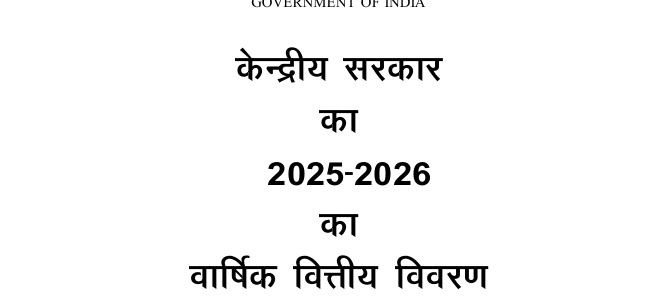

In [21]:
tables = [el for el in all_elements if el.category == "Table"]
tables

[]

In [22]:
all_elements[11].to_dict()

{'type': 'CompositeElement',
 'element_id': '6658ec68b9e0efc9f686e79ea2f51677',
 'text': 'Commodities and Services\n\n(ङ) िवधानमंडल रिहत संघ रा(cid:475) (cid:407)े(cid:361)ों के\n\n(e) Taxes of Union Territories\n\n3745.09\n\n4526.40\n\nकर सकल कर राज(cid:738) समेिकत िनिध म(cid:336) शािमल न िकये गए\n\nरा(cid:475)ों का भाग',
 'metadata': {'file_directory': '..\\data\\pdfs',
  'filename': 'allafs.pdf',
  'last_modified': '2026-01-16T13:09:09',
  'page_number': 3,
  'orig_elements': 'eJzVVstu2zoQ/RVBqxoIBb4f2d79xQXqruLCoMhhQsCWDFnpTVr030uRcq2kLtouDKSAQfNwZkiKZ4aHd19q2MEeunEbfX1b1VYpJUEQRLxwiHNlkAGrkXaWa+sD5t7XN1W9h9F6O9oU86V2fT/42NkRjhnv7HP/OG4fIN4/jGlEc9Jok6Jmw//Rjw9pXBjRUCWT4dDHbpyC7+6IwQ2+qTjnjfx4U33HghZMtWjIBZz900B9fD6OsJ8+5r/4BLv3B+ug/poMIe5g6+MAbuyH58mhaTab6Ss2m4MPx3r26ewe8lnsdjYcm2Sq896P43bf+xgi5KOimEqE00nJNWG32KTf5Hew97DtHvctDMmLTQuP8DQdQ/1Pv58mGCMcK9v56j0Mn6KDvPD4fMiLruO4y9t9zYxngTsaAqIkKMSdsMjaliAlpTVMC+r5tZnRhQjR4ExMgZLNUJBGXcDZ/W3z8m7ziA0xq2r6ZyG3Ymqpyn3IfZ3b3Mc090m20hKGF8Emm3k

Our PDF visually has a table with:

Hindi + English headers

Numeric columns aligned properly

But internally, the PDF is stored as:

Absolutely positioned text blocks

No real “table structure”

So Unstructured is extracting text, not a table, and it ends up as:

```
Commodities and Services
(e) Taxes of Union Territories
3745.09
4526.40
कर सकल कर राज...
-> Row/column relationships are lost
```

Government and budget PDFs often lack true table structure; Unstructured extracts them as text, so numeric tables should be handled with a dedicated table extraction pipeline when accuracy matters.

In [23]:
# Better approach - ALL elements for hybrid retrieval

for el in all_elements:
    print(f"{el.category:15} | Page {el.metadata.page_number} | {el.text[:30]}...")

CompositeElement | Page 1 | £ÉÉ®iÉ ºÉ®BÉEÉ® GOVERNMENT OF ...
CompositeElement | Page 1 | xÉ<Ç ÉÊnããÉÉÒ, 1 {ÉE®´É®ÉÒ, 20...
CompositeElement | Page 1 | Statement I - Consolidated Fun...
CompositeElement | Page 1 | Statement I A - Disbursements ...
CompositeElement | Page 1 | |ÉÉÉÎ{iÉªÉÉÆ ºÉÆÉÊ´ÉiÉ®hÉ

Rec...
CompositeElement | Page 3 | मु(cid:421) शीष(cid:330) Major...
CompositeElement | Page 3 | A. TAX REVENUE (a) Goods and S...
CompositeElement | Page 3 | Union Territory Goods and Serv...
CompositeElement | Page 3 | Corporation Tax

होटल (cid:366...
CompositeElement | Page 3 | Expenditure

(ग) संपि(cid:517)...
CompositeElement | Page 3 | Services other than Goods and ...
CompositeElement | Page 3 | Commodities and Services

(ङ) ...
CompositeElement | Page 3 | without Legislature

GROSS TAX...
CompositeElement | Page 3 | Government

2336024.87

259295...
CompositeElement | Page 3 | B. NON-TAX REVENUE (a) Fiscal ...
CompositeElement | Page 3 | Profits

(cid:623)ाज (cid:366)...
Composit

### **Chunking**

In [64]:
# Create proper chunks with metadata
chunks = []

for el in all_elements:
    chunk = {
        "content": el.text,
        "category": el.category,  # Title, Table, Text, etc.
        "page": el.metadata.page_number,
        #"source": el.metadata.filename,
        "is_table": el.category == "Table",
        "table_html": el.metadata.text_as_html if el.category == "Table" else None
    }
    chunks.append(chunk)

print(f"---> {len(chunks)} chunks ready for BM25 + Semantic indexing")

---> 8139 chunks ready for BM25 + Semantic indexing


In [65]:
# IGNORE = {"Header", "Footer", "UncategorizedText"}

IGNORE = {"Footer", "UncategorizedText"}

elements = [
    el for el in all_elements
    if el.category not in IGNORE and el.text.strip()
]

In [66]:
print(len(elements))
elements[:5][2].to_dict()

8139


{'type': 'CompositeElement',
 'element_id': '92c238df00a6378a76335cca77373036',
 'text': 'Statement I - Consolidated Fund of India -\n\n®ÉVÉº´É JÉÉiÉÉ - |ÉÉÉÎ{iÉªÉÉÆ ®ÉVÉº´É JÉÉiÉÉ - ºÉÆÉÊ´ÉiÉ®hÉ {ÉÚÆVÉÉÒ JÉÉiÉÉ - |ÉÉÉÎ{iÉªÉÉÆ {ÉÚÆVÉÉÒ JÉÉiÉÉ - ºÉÆÉÊ´ÉiÉ®hÉ ÉÊ´É´É®hÉ I BÉE - £ÉÉ®iÉ BÉEÉÒ ºÉÆÉÊSÉiÉ ÉÊxÉÉÊvÉ {É®\n\nRevenue Account - Receipts Revenue Account - Disbursements Capital Account - Receipts Capital Account - Disbursements',
 'metadata': {'file_directory': '..\\data\\pdfs',
  'filename': 'allafs.pdf',
  'last_modified': '2026-01-16T13:09:09',
  'page_number': 1,
  'orig_elements': 'eJzNVUuPmzAQ/isW5xiZl4G9tdtWSk/VJt1LsooGPCSWCCAw26Rp/3ttYBvyaHvoRloJGX8z37zBXhwszHGLhVpJYd0RK3GZcN0MKQShS32RRjTmwqUshtjzUSu5sCbE2qICAQq0zcFKy7IWsgCFTYdz2JetWm1QrjdKSyLftZk2GuTfpFAbLQ7ioBNXpSyUsVwsPMcxoiBmtv80IUcc257BfqQ317Dha4HV7BuFW1PJF7nDfFZBitZPrchkjisha0xVWe8NwbaXS1PCclmJrLEGTgFbNFrIc8gaW6usLvNGrbalkJnErk8uczllDnX43PHuWKwfw6tgjaui3SZYa5ZjAivcmR5YM6X7YzpNpoSS+7Joylzq+CjIp7YQpMzItBASCDWO1L7q0phLlXcFn

In [67]:
# Group elements by section title to improve chunking and retrieval

from collections import defaultdict

sections = []
current_section = {
    "title": None,
    "elements": [],
    "page_start": None
}

for el in elements:
    if el.category == "Title":
        if current_section["elements"]:
            sections.append(current_section)

        current_section = {
            "title": el.text,
            "elements": [],
            "page_start": el.metadata.page_number
        }
    else:
        current_section["elements"].append(el)

# flush
if current_section["elements"]:
    sections.append(current_section)

In [68]:
current_section

{'title': None,
 'elements': [<unstructured.documents.elements.CompositeElement at 0x1f95f28d070>,
  ...],
 'page_start': None}

In [69]:
# Section wise chunking: grouping by titles and splitting large sections

from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,       # or 500-700 tokens
    chunk_overlap=200,     # optional
    separators=["\n\n", "\n", ". ", " "]

)

chunks = []

for sec in sections:
    # merge section text
    section_text = "\n\n".join(el.text for el in sec["elements"])

    # split section into chunks
    sub_chunks = splitter.split_text(section_text)

    # prepend title to each sub-chunk
    for sub in sub_chunks:
        cleaned = sub.lstrip(" .\n")
        chunks.append({
            "content": f"{sec['title']}\n\n{cleaned}",
            "title": sec['title'],                    # section title
            "page_start": sec['page_start'],          # first page of section
            "page_end": sec['elements'][-1].metadata.page_number,  # last page of section
            "source": sec['elements'][0].metadata.filename,        # file name
            "category": [el.category for el in sec["elements"]]   # list of element types
        })

In [70]:
for i, ch in enumerate(chunks[:4]):
    print(f"\n--- Chunk {i} ---")
    print(ch["content"])


--- Chunk 0 ---
None

£ÉÉ®iÉ ºÉ®BÉEÉ® GOVERNMENT OF INDIA

BÉäExpÉÒªÉ ºÉ®BÉEÉ® BÉEÉ 2025-2026 BÉEÉ ´ÉÉÉÌKÉBÉE ÉÊ´ÉkÉÉÒªÉ ÉÊ´É´É®hÉ ANNUAL FINANCIAL STATEMENT OF THE CENTRAL GOVERNMENT FOR 2025-2026

(VÉèºÉÉ ºÉÆºÉn àÉå |ÉºiÉÖiÉ ÉÊBÉEªÉÉ MÉªÉÉ) (As laid before Parliament)

xÉ<Ç ÉÊnããÉÉÒ, 1 {ÉE®´É®ÉÒ, 2025 New Delhi, February 1, 2025

ÉÊxÉàÉÇãÉÉ ºÉÉÒiÉÉ®ÉàÉxÉ ÉÊ´ÉkÉ àÉÆjÉÉÒ Nirmala Sitharaman Minister of Finance

ÉÊ´ÉKÉªÉ ºÉÚSÉÉÒ CONTENTS

ÉÊ´É´É®hÉ I - £ÉÉ®iÉ BÉEÉÒ ºÉÆÉÊSÉiÉ ÉÊxÉÉÊvÉ -

Statement I - Consolidated Fund of India -

®ÉVÉº´É JÉÉiÉÉ - |ÉÉÉÎ{iÉªÉÉÆ ®ÉVÉº´É JÉÉiÉÉ - ºÉÆÉÊ´ÉiÉ®hÉ {ÉÚÆVÉÉÒ JÉÉiÉÉ - |ÉÉÉÎ{iÉªÉÉÆ {ÉÚÆVÉÉÒ JÉÉiÉÉ - ºÉÆÉÊ´ÉiÉ®hÉ ÉÊ´É´É®hÉ I BÉE - £ÉÉ®iÉ BÉEÉÒ ºÉÆÉÊSÉiÉ ÉÊxÉÉÊvÉ {É®

Revenue Account - Receipts Revenue Account - Disbursements Capital Account - Receipts Capital Account - Disbursements

Statement I A - Disbursements ‘Charged’

1-3 4-6 7 8-10

‘£ÉÉÉÊ®iÉ’ ºÉÆÉÊ´ÉiÉ®hÉ

on the Consolidated Fund of India

11-12

ÉÊ´É´É®hÉ II - £ÉÉ®iÉ BÉEÉÒ +ÉÉBÉEÉÎºàÉBÉEiÉÉ

# Interpretation: PDF Ingestion Challenges in Multilingual Government Documents

## Overview

During document ingestion, certain PDF files—particularly Indian government and budget documents—exhibit inconsistent text extraction quality. This behavior is not caused by chunking strategies, prompt design, or retrieval logic, but by underlying issues related to **PDF encoding and font usage**.

These PDFs often contain a mixture of English and Hindi text, along with structured tables and numerical data. While numerical values are generally extracted correctly, textual content—especially Hindi—may appear garbled or unreadable.

---

## Root Cause Analysis

### Legacy Non-Unicode Fonts

Many government PDFs use **legacy, non-Unicode fonts** (such as Kruti Dev or custom CID-based fonts). In these cases:

* Text is stored as font glyph positions rather than Unicode characters.
* Extracted output may appear as corrupted Latin characters (e.g., `£ÉÉ®iÉ ºÉ®BÉEÉ®`) instead of readable Hindi text.
* This is a **font-encoding issue**, not an OCR or parsing error.

### Mixed Encoding Within a Single Document

It is common for a single PDF to contain:

* Sections using legacy font encodings
* Sections using proper Unicode text

As a result:

* Some Hindi text extracts correctly
* Other Hindi text becomes unreadable
* English text and numbers usually remain intact

---

## Why Standard Extraction Fails

Libraries such as **Unstructured** extract text objects as they exist in the PDF. They do not:

* Remap legacy font encodings
* Transliterate glyph-based text
* Repair corrupted character mappings

Therefore, extraction faithfully reproduces the underlying encoding—even if it is unreadable.

---

## PDF Complexity Classification

These documents fall under a higher difficulty category for ingestion:

| Tier       | Description                      |
| ---------- | -------------------------------- |
| Tier 1     | Born-digital, clean Unicode PDFs |
| Tier 2     | Unicode multilingual PDFs        |
| **Tier 3** | Legacy-font government PDFs      |
| Tier 4     | Fully scanned image PDFs         |

Tier-3 PDFs can be more problematic than scanned documents because text appears present but is semantically corrupted.

---

## Impact on Tables and Numerical Data

* Numeric values extract correctly because they use standard ASCII characters.
* Table headers and labels may be corrupted if they rely on legacy fonts.
* This causes partial loss of semantic meaning even when row values are intact.

As a result, tables may appear structurally correct but lack reliable context.

---

## Recommended Ingestion Strategy

### Force OCR for Legacy PDFs (Preferred)

To reliably extract multilingual text, ingestion should **force OCR even when text exists** in the PDF:

* OCR captures visual text instead of embedded glyphs
* Produces proper Unicode output for Hindi and English
* Improves chunk quality, retrieval accuracy, and RAG stability

This approach is slower but significantly more accurate.

---

### Conditional OCR (Production-Grade Approach)

A robust ingestion pipeline may:

1. Attempt standard extraction
2. Detect garbled text patterns (non-ASCII-heavy output)
3. Re-run OCR selectively for affected pages

This balances performance and correctness.

---

## Approaches Not Recommended

* Manual font-to-Unicode post-processing
* Custom glyph remapping logic

These solutions are font-specific, brittle, and difficult to maintain.

---

## Implications for RAG Systems

Without OCR:

* Retrieved chunks may be inconsistent
* Answers may vary across generations
* Rerankers may select semantically incorrect text

With OCR:

* Chunks are linguistically stable
* Multilingual retrieval improves
* Factual consistency increases
* Hallucinations decrease

---

## Key Takeaway

> Indian government PDFs frequently use legacy non-Unicode fonts, resulting in corrupted text extraction. Reliable ingestion requires forcing OCR even when textual content appears to be present.

---

## Final Recommendation

For document ingestion pipelines:

| Document Type         | Strategy                                |
| --------------------- | --------------------------------------- |
| Budget / Finance PDFs | Hi-res OCR ingestion                    |
| Research / Reports    | Fast text extraction                    |
| Mixed collections     | Encoding detection with conditional OCR |

This approach ensures reliable downstream retrieval, question answering, and analytics.

In [71]:
chunks[0]['content']

'None\n\n£ÉÉ®iÉ ºÉ®BÉEÉ® GOVERNMENT OF INDIA\n\nBÉäExpÉÒªÉ ºÉ®BÉEÉ® BÉEÉ 2025-2026 BÉEÉ ´ÉÉÉÌKÉBÉE ÉÊ´ÉkÉÉÒªÉ ÉÊ´É´É®hÉ ANNUAL FINANCIAL STATEMENT OF THE CENTRAL GOVERNMENT FOR 2025-2026\n\n(VÉèºÉÉ ºÉÆºÉn àÉå |ÉºiÉÖiÉ ÉÊBÉEªÉÉ MÉªÉÉ) (As laid before Parliament)\n\nxÉ<Ç ÉÊnããÉÉÒ, 1 {ÉE®´É®ÉÒ, 2025 New Delhi, February 1, 2025\n\nÉÊxÉàÉÇãÉÉ ºÉÉÒiÉÉ®ÉàÉxÉ ÉÊ´ÉkÉ àÉÆjÉÉÒ Nirmala Sitharaman Minister of Finance\n\nÉÊ´ÉKÉªÉ ºÉÚSÉÉÒ CONTENTS\n\nÉÊ´É´É®hÉ I - £ÉÉ®iÉ BÉEÉÒ ºÉÆÉÊSÉiÉ ÉÊxÉÉÊvÉ -\n\nStatement I - Consolidated Fund of India -\n\n®ÉVÉº´É JÉÉiÉÉ - |ÉÉÉÎ{iÉªÉÉÆ ®ÉVÉº´É JÉÉiÉÉ - ºÉÆÉÊ´ÉiÉ®hÉ {ÉÚÆVÉÉÒ JÉÉiÉÉ - |ÉÉÉÎ{iÉªÉÉÆ {ÉÚÆVÉÉÒ JÉÉiÉÉ - ºÉÆÉÊ´ÉiÉ®hÉ ÉÊ´É´É®hÉ I BÉE - £ÉÉ®iÉ BÉEÉÒ ºÉÆÉÊSÉiÉ ÉÊxÉÉÊvÉ {É®\n\nRevenue Account - Receipts Revenue Account - Disbursements Capital Account - Receipts Capital Account - Disbursements\n\nStatement I A - Disbursements ‘Charged’\n\n1-3 4-6 7 8-10\n\n‘£ÉÉÉÊ®iÉ’ ºÉÆÉÊ´ÉiÉ®hÉ\n\non the Consolidated Fund of India\n\n11-12\n\nÉÊ´É´É®hÉ II - £ÉÉ®iÉ BÉEÉÒ +

In [72]:
chunks[4]

{'content': "None\n\nServices other than Goods and Services Tax\n\n0030 0031 0032 0034\n\n0.31 1.31 6.12 33777.78 543249.51\n\n... ... ... 37000.00 561845.00\n\nBanking Cash Transaction Tax Customs Union Excise Duties Sales Tax Service Tax\n\nब(cid:339)िकंग नकद सं(cid:681)वहार कर सीमा शु(cid:651) क(cid:336)(cid:363)ीय उ(cid:523)ाद शु(cid:651) िब(cid:354)ी कर सेवा कर व(cid:721)ु और सेवाओं पर अ(cid:586) कर और शु(cid:651) Other Taxes and Duties on\n\n0036 0037 0038 0040 0044 0045\n\n414.32 233118.97 305362.18 ... 424.96 3929.08\n\n... 237745.00 319000.00 ... 100.00 5000.00\n\nCommodities and Services\n\n(ङ) िवधानमंडल रिहत संघ रा(cid:475) (cid:407)े(cid:361)ों के\n\n(e) Taxes of Union Territories\n\n3745.09\n\n4526.40\n\nकर सकल कर राज(cid:738) समेिकत िनिध म(cid:336) शािमल न िकये गए\n\nरा(cid:475)ों का भाग\n\nwithout Legislature\n\nGROSS TAX REVENUE State's share excluded from the Consolidated Fund\n\n3465518.58 1129493.71\n\n3840170.40 1247211.28\n\nक(cid:336)(cid:363) सरकार का कर राज(cid:

In [73]:
len(chunks)

5596

In [74]:
# Find the element with text "References" and category "Title"
title = [
    el for el in all_elements
    if el.category == "Title"
]

In [75]:
title

[]

In [76]:
sections[0]
section_text = "\n\n".join(el.text for el in sec["elements"])

In [83]:
print(len(section_text))
section_text[:100]

4355565


'£ÉÉ®iÉ ºÉ®BÉEÉ® GOVERNMENT OF INDIA\n\nBÉäExpÉÒªÉ ºÉ®BÉEÉ® BÉEÉ 2025-2026 BÉEÉ ´ÉÉÉÌKÉBÉE ÉÊ´ÉkÉÉÒªÉ É'

In [78]:
sections

[{'title': None,
  'elements': [<unstructured.documents.elements.CompositeElement at 0x1f95f28d070>,
   ...],
  'page_start': None}]

In [90]:
len(sections)

1

In [84]:
# Generate embeddings and index with Chroma

from langchain_core.documents import Document
from langchain_ollama import OllamaEmbeddings
from langchain_chroma import Chroma

chunk_docs = [
    Document(
        page_content=chunk["content"],
        metadata={
            "title": chunk["title"],
            "page_start": chunk["page_start"],
            "page_end": chunk["page_end"],
            "source": chunk["source"],
            "category": ", ".join(chunk["category"])  # convert list to string
        }
    )
    for chunk in chunks
]

print("Generating embeddings and indexing...")
embeddings = OllamaEmbeddings(model="nomic-embed-text")

vectorstore = Chroma.from_documents(
    documents=chunk_docs,
    embedding=embeddings,
    persist_directory="./chroma_db",
    collection_name="unstructured_test"
)

Generating embeddings and indexing...


In [85]:
# Test retrieval
vectorstore_retriever = vectorstore.as_retriever(
    search_kwargs={"k": 5}
)

# Test query
query = "Graduation rates of Students with disabilities in higher education institutions"
relevant_docs = vectorstore_retriever.invoke(query)

print(f"Found {len(relevant_docs)} relevant chunks:")
for doc in relevant_docs:
    print("\n---")
    print(f"Source: {doc.metadata['source']}")
    #print(f"Pages: {doc.metadata['page_start']} - {doc.metadata['page_end']}") - None values for some chunks
    #print(f"Title: {doc.metadata['title']}") - None values for some chunks
    print(f"Content: {doc.page_content[:500]}...")

Found 5 relevant chunks:

---
Source: allafs.pdf
Content: None

Scholarship for Students with Disabilidties:..The main objective of the umbrella scholarship Scheme is to empower students with disabilities to study further in order to earn their livelihood and to find a dignified place in the society, as they face several barriers-physical, financial, and psychological in pursuing studies and living with dignity,

6.

7.

National University of Rehabilitation Science and Disabiltiy Studies:..This provision is

made for setting up a National University o...

---
Source: allafs.pdf
Content: None

Scholarship for Students with Disabilidties:..The main objective of the umbrella scholarship Scheme is to empower students with disabilities to study further in order to earn their livelihood and to find a dignified place in the society, as they face several barriers-physical, financial, and psychological in pursuing studies and living with dignity,

6.

7.

National University of Rehabilitation 

In [86]:
similar_docs = vectorstore.similarity_search("Graduation rates of Students with disabilities in higher education institutions")

for doc in similar_docs:
    print("\n---")
    print(f"Source: {doc.metadata['source']}")
    #print(f"Pages: {doc.metadata['page_start']} - {doc.metadata['page_end']}")
    #print(f"Title: {doc.metadata['title']}")
    print(f"Content: {doc.page_content[:500]}...")


---
Source: allafs.pdf
Content: None

Scholarship for Students with Disabilidties:..The main objective of the umbrella scholarship Scheme is to empower students with disabilities to study further in order to earn their livelihood and to find a dignified place in the society, as they face several barriers-physical, financial, and psychological in pursuing studies and living with dignity,

6.

7.

National University of Rehabilitation Science and Disabiltiy Studies:..This provision is

made for setting up a National University o...

---
Source: allafs.pdf
Content: None

Scholarship for Students with Disabilidties:..The main objective of the umbrella scholarship Scheme is to empower students with disabilities to study further in order to earn their livelihood and to find a dignified place in the society, as they face several barriers-physical, financial, and psychological in pursuing studies and living with dignity,

6.

7.

National University of Rehabilitation Science and Disabiltiy St

In [89]:
chunks[500]

{'content': 'None\n\n2235\n\n13.54\n\n13.71\n\nपोषण\n\nNutrition\n\n2236\n\n0.88\n\n0.79\n\n(cid:366)ाकृितक आपदा राहत\n\nRelief on account of Natural Calamities\n\n2245\n\n0.17\n\n0.26\n\nकृिष काय(cid:330)\n\nCrop Husbandry\n\n2401\n\n12.54\n\n13.79\n\nमृदा और जल संर(cid:407)ण\n\nSoil and Water Conservation\n\n2402\n\n0.19\n\n0.23\n\nपशु पालन\n\nAnimal Husbandry\n\n2403\n\n6.94\n\n8.23\n\nम(cid:536) पालन\n\nFisheries\n\n2405\n\n12.10\n\n12.95\n\nवािनकी और व(cid:586) जीव\n\nForestry and Wild Life\n\n2406\n\n1.19\n\n1.22\n\nखा(cid:552) भंडारण और माल गोदाम\n\nFood Storage and Warehousing\n\n2408\n\n2.57\n\n2.95\n\nCo-operation\n\nसहका(cid:303)रता (cid:356)ामीण िवकास के िलए िवशेष काय(cid:330)(cid:354)म Special Programmes for Rural\n\n2425\n\n2501\n\n2.80\n\n0.87\n\n3.01\n\n1.04\n\n(cid:356)ामीण रोजगार\n\nDevelopment Rural Employment\n\n2505\n\n0.08\n\n0.10\n\nअ(cid:586) (cid:356)ामीण िवकास काय(cid:330)(cid:354)म\n\nOther Rural Development Programmes\n\n2515\n\n10.03\n\n12.51\n\nिवद्युत\n\n

In [88]:
all_elements[:][1045].to_dict()

{'type': 'CompositeElement',
 'element_id': '6028ac4350da05cbe90070543b6dfd21',
 'text': 'ंजीगत\n\nCapital Outlay on Forestry and Wild Life\n\n4406\n\n33.91\n\n19.40\n\nसहका(cid:303)रता पर पू\n\nंजीगत प(cid:303)र(cid:681)य\n\nCapital Outlay on Co-operation\n\n4425\n\n...\n\n0.01\n\nवृहत और म(cid:559)म िसंचाई पर पू प(cid:303)र(cid:681)य',
 'metadata': {'file_directory': '..\\data\\pdfs',
  'filename': 'alldg.pdf',
  'last_modified': '2026-01-16T13:09:04',
  'page_number': 85,
  'orig_elements': 'eJzVl01v20YQhv8KwVMLeBf7Mfvla4CeirZAXfQQB8Zwd2gTkERBotu4Qf97l0syURUZiA4KZB0IvcshRM2j5Tx6/6mmFa1pMzx0qb6taokyGBUbFqFpGQQAhkSRNa0kgUmpSK6+qeo1DZhwwHzNpzr2/S51GxxoX/IKX/rn4eGJusenIa8EZbjKF83rf3dpeMrLJhgOkNe3fbcZxkvfv89L7qYyYLn8cFMt0WhuxyglcHsil/K8UO9f9gOtxy/yW/eRVr9vMVL9bz7Rdit6SN2O4tDvXsYCzu/vx29wf79N7b6eaza4pvEsrlbpkeczdbnv/fCw7lPXdlS6pISyTEgm7Z3UtyLcChjrtvhID5vndUO7XOXN+MEDfRxbUN8/iyDUeJRxPIIo7914VOXq4WVbPvquG1blpo/ZRGlbbMmzYNExQJMYeueZN01SUkgdTbwkG6kl12O3gYfS/TlbOWUFiosTudRfN513uO0GXFW/Pg+5EVW/

In [92]:
similar_docs = vectorstore.similarity_search("Graduation rates of Students with disabilities in higher education institutions")

for doc in similar_docs:
    print("\n---")
    print(f"Source: {doc.metadata['source']}")
    #print(f"Pages: {doc.metadata['page_start']} - {doc.metadata['page_end']}")
    #print(f"Title: {doc.metadata['title']}")
    print(f"Content: {doc.page_content[:500]}...")


---
Source: allafs.pdf
Content: None

Scholarship for Students with Disabilidties:..The main objective of the umbrella scholarship Scheme is to empower students with disabilities to study further in order to earn their livelihood and to find a dignified place in the society, as they face several barriers-physical, financial, and psychological in pursuing studies and living with dignity,

6.

7.

National University of Rehabilitation Science and Disabiltiy Studies:..This provision is

made for setting up a National University o...

---
Source: allafs.pdf
Content: None

Scholarship for Students with Disabilidties:..The main objective of the umbrella scholarship Scheme is to empower students with disabilities to study further in order to earn their livelihood and to find a dignified place in the society, as they face several barriers-physical, financial, and psychological in pursuing studies and living with dignity,

6.

7.

National University of Rehabilitation Science and Disabiltiy St

In [93]:
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [94]:
# Testing LLM Response Just with a minimal Prompt Template

from langchain_core.runnables import RunnablePassthrough
from langchain_ollama import OllamaLLM
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Your llama2 model for answering
llm = OllamaLLM(model="qwen2.5:1.5b")

# Convert vectorstore to a retriever
vectorstore_retriever = vectorstore.as_retriever()

# Define the prompt template
prompt_template = """
Use the following context to answer the question as accurately as possible.
If the answer is not present in the context, say "Not available".

Context:
{context}

Question:
{question}

Answer:
"""
prompt = ChatPromptTemplate.from_template(prompt_template)

# Create the chain
rag_chain = (
    {"context": vectorstore_retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
)

# Invoke with just the question string
question = "Graduation rates of Students with disabilities in higher education institutions"
answer = rag_chain.invoke(question)

print(f"Q: {question}")
print("Ans: " + answer)

Q: Graduation rates of Students with disabilities in higher education institutions
Ans: Not available.


In [95]:
# Invoke with just the question string
question = "What are the challenges mentioned here?"
answer = rag_chain.invoke(question)

print(f"Q: {question}")
print("Ans: " + answer)

Q: What are the challenges mentioned here?
Ans: The context does not provide specific challenges or obstacles that need to be addressed during this period. It focuses on India's economic growth, inclusive development, private sector investments, and boosting the spending power of its rising middle class under Prime Minister Narendra Modi's leadership. The text mentions geopolitical headwinds but does not elaborate on them in detail.


In [98]:
from langchain_community.retrievers import BM25Retriever

bm25_retriever = BM25Retriever.from_documents(
    chunk_docs,
    bm25_variant="plus",    
)

In [99]:
result = bm25_retriever.invoke("retrieval augmented generation")
result

[Document(metadata={'title': None, 'page_start': None, 'page_end': 300, 'source': 'allafs.pdf', 'category': 'CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, Composite

In [100]:
import hashlib

def doc_hash(doc):
    return hashlib.md5(doc.page_content.encode("utf-8")).hexdigest()

In [101]:
# Hybrid Retriever using RRF

class HybridRetriever:
    def __init__(self, bm25_retriever, vector_retriever, weights=[0.5, 0.5]):
        self.bm25_retriever = bm25_retriever
        self.vector_retriever = vector_retriever
        self.bm25_weight = weights[0]
        self.vector_weight = weights[1]

    def invoke(self, query, k=5):
        bm25_docs = self.bm25_retriever.invoke(query)
        vector_docs = self.vector_retriever.invoke(query)

        rrf_k = 60
        doc_scores = {}
        doc_map = {}

        # BM25
        for rank, doc in enumerate(bm25_docs, 1):
            key = doc_hash(doc)
            doc_scores[key] = self.bm25_weight / (rrf_k + rank)
            doc_map[key] = doc

        # Vector
        for rank, doc in enumerate(vector_docs, 1):
            key = doc_hash(doc)
            score = self.vector_weight / (rrf_k + rank)
            doc_scores[key] = doc_scores.get(key, 0) + score
            doc_map[key] = doc

        ranked = sorted(doc_scores.items(), key=lambda x: x[1], reverse=True)
        return [doc_map[k] for k, _ in ranked[:k]]

# Create hybrid retriever
hybrid_retriever = HybridRetriever(
    bm25_retriever=bm25_retriever,
    vector_retriever=vectorstore_retriever,
    weights=[0.5, 0.5]
)

# Test it
docs = hybrid_retriever.invoke("How does the 'compare' feature proposed for Phase 3 depend on the 'HXL-ation' process?", k=5)
print(f"---> Got {len(docs)} hybrid results")

---> Got 5 hybrid results


In [103]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 1092.88it/s, Materializing param=classifier.weight]                                    
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [104]:
def rerank_docs(query, docs, top_k=5):
    """
    query: str
    docs: List[Document]
    top_k: int
    """

    # Prepare (query, doc_text) pairs
    pairs = [(query, doc.page_content) for doc in docs]

    # Get relevance scores
    scores = reranker.predict(pairs)

    # Attach scores to docs
    scored_docs = list(zip(docs, scores))

    # Sort by score (descending)
    scored_docs.sort(key=lambda x: x[1], reverse=True)

    # Return top-k docs only
    return [doc for doc, score in scored_docs[:top_k]]

In [105]:
query = "How does the 'compare' feature proposed for Phase 3 depend on the 'HXL-ation' process?"
candidate_docs = hybrid_retriever.invoke(query, k=20)

In [106]:
candidate_docs

[Document(id='602952ff-55c6-43b7-b202-6de3c9b2fe8f', metadata={'page_end': 300, 'source': 'allafs.pdf', 'category': 'CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, C

In [108]:
final_docs = rerank_docs(query, candidate_docs, top_k=5)
final_docs

[Document(metadata={'title': None, 'page_start': None, 'page_end': 300, 'source': 'allafs.pdf', 'category': 'CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, CompositeElement, Composite

In [109]:
def build_structured_context(docs):
    context_blocks = []
    source_map = {}

    for i, doc in enumerate(docs, 1):
        context_blocks.append(
            f"""
[Source {i}]
Document: {doc.metadata['source']}
Section: {doc.metadata.get('title', 'N/A')}
Pages: {doc.metadata.get('page_start')}–{doc.metadata.get('page_end')}

Content:
{doc.page_content}
""".strip()
        )

        source_map[i] = {
            "file": doc.metadata["source"],
            "section": doc.metadata.get("title"),
            "pages": f"{doc.metadata.get('page_start')}–{doc.metadata.get('page_end')}"
        }

    return "\n\n---\n\n".join(context_blocks), source_map

structured_context, source_map = build_structured_context(final_docs)
print("Structured Context:\n")
print(structured_context)

Structured Context:

[Source 1]
Document: allafs.pdf
Section: None
Pages: None–300

Content:
None

7. Amendment of definition of ‘capital asset’:

In order to bring clarity on the chargeability of income arising out of transfer of capital asset being securities held by an investment fund as referred to in section 115UB of the Act, the definition of capital asset is proposed to be amended.

8. Rationalization of transfer pricing provisions for carrying out multi-year arm’s length price determination

It is proposed to provide that the transfer pricing provisions for arm’s length price determination in relation to similar transactions shall now be applicable for a period of 3 years.

52

9. Exemption from prosecution for delayed payment of TCS:

It is proposed to provide for exemption from prosecution to a person who has failed to pay tax collected at source (TCS) to the credit of the Central Government, if such payment is made at any time on or before the time prescribed for filing the 

In [110]:
# LLM Integration

from langchain_ollama import OllamaLLM
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Initializing the Qwen2.5:1.5b model
llm = OllamaLLM(
    model="qwen2.5:1.5b",
    temperature=0.0,
    top_p=1.0
)

In [111]:
prompt_template = ChatPromptTemplate.from_template("""
You are a research assistant answering questions strictly from the provided document context.

CRITICAL RULES (NON-NEGOTIABLE):
1. Use ONLY the information explicitly stated in the context.
2. Do NOT use prior knowledge, assumptions, interpretations, or reasoning beyond the text.
3. Every factual sentence MUST end with a citation in the form [Source X].
4. If a question has multiple sub-questions, ALL parts must be answered.
5. If ANY part of the question cannot be answered from the context, DO NOT partially answer.

MISSING INFORMATION HANDLING:
If required information is missing or unclear, respond ONLY with:
"I couldn’t find this information in the available documents."
                                                   
CRITICAL ANSWERABILITY RULE:
The question may contain multiple sub-questions.
You must answer ONLY if ALL sub-questions are explicitly and clearly answered in the provided context.

If ANY sub-question is missing, unclear, or indirectly implied,
respond ONLY with:

"I could not find information related to this question according to the provided documents."

Do not provide partial answers.
Do not summarize unrelated sections.
Do not include Sources Summary when refusing.


PROHIBITED BEHAVIOR:
- Do NOT speculate or infer timelines, durations, or participants.
- Do NOT explain why the information is missing.
- Do NOT summarize document structure or page counts.
- Do NOT reinterpret or restate the user's question.
- Do NOT include phrases like "it appears", "based on the information", or "indicates that".

CONTEXT:
The following are retrieved document sections. Each section is identified by a source number.                                                                                                   

{context}

QUESTION:
{question}

ANSWER FORMAT:
- Use bullet points if applicable.
- Each sentence must end with one or more citations.
- Do NOT include a references list.
- Do NOT repeat the context.

ANSWER:
""")

In [112]:
rag_chain = (
    prompt_template
    | llm
    | StrOutputParser()
)

In [113]:
def format_reranked_sources(docs):
    """
    Convert reranked Document objects into a clean, readable source list
    """
    formatted = []

    for i, doc in enumerate(docs):
        meta = doc.metadata or {}

        source = meta.get("source", "Unknown")
        title = meta.get("title", "Unknown")
        page_start = meta.get("page_start", "?")
        page_end = meta.get("page_end", "?")

        formatted.append(            
            f"[{i+1}] Source: {source}\n"
            f"Title: {title}\n"
            f"Pages: {page_start}–{page_end}"
        )

    return "\n\n".join(formatted)

In [114]:
def answer_query(
    query: str,
    *,
    hybrid_retriever,
    reranker,
    rag_chain,
    top_k_retrieval: int = 20,
    top_k_rerank: int = 5
):
    """
    End-to-end RAG pipeline:
    Query → Hybrid Retrieval → Re-ranking → Structured Context → LLM Answer
    """

    # 1️. Stage-1: Hybrid Retrieval (BM25 + Vector)
    candidate_docs = hybrid_retriever.invoke(
        query,
        k=top_k_retrieval
    )

    if not candidate_docs:
        return "I couldn’t find relevant information for this question in the documents."

    # 2️. Stage-2: Re-ranking (Cross-encoder)
    reranked_docs = rerank_docs(
        query=query,
        docs=candidate_docs,
        top_k=top_k_rerank
    )



    if not reranked_docs:
        return "I found documents, but none were relevant enough after re-ranking."

    # 3️. Build structured context with source indices
    context_text = build_structured_context(reranked_docs)

    # 4️. LLM generation
    response = rag_chain.invoke({
        "context": context_text,
        "question": query
    })

    sources_summary = format_reranked_sources(reranked_docs)

    return response, sources_summary

In [115]:
query = "Graduation rates of Students with disabilities in higher education institutions"

response = answer_query(
    query=query,
    hybrid_retriever=hybrid_retriever,
    reranker=reranker,
    rag_chain=rag_chain,
    top_k_retrieval=20,
    top_k_rerank=5
)

print("LLM Response:\n")
print(response)

LLM Response:

('- The total percentage of students among all completing higher studies who are from Scheduled Tribes (ST) is 4,000 out of 25,000. [Source 1]\n- Scholarships for ST Students: Financial assistance provided to ST students for higher education in abroad and scholarships for higher studies include PhDs. [Source 3]\n- Venture Capital Fund for Scheduled Tribes: Financial assistance at concessional rate is provided to ST entrepreneurs. [Source 2]\n- Support of ST Entrepreneurs: No. of ST entrepreneurs supported through the venture capital fund. [Source 2]\n- MoTA recognized Tribal Research Information, Education, Communication and Events (TRI-ECE): Number of projects under TRI-ECE. [Source 4]\n- National University of Rehabilitation Science and Disability Studies: Provision made for setting up a national university in rehabilitation science and disability studies. [Source 3]\n- Centre for Disability Sports: Encourages persons with disabilities to pursue sports, providing profe

In [118]:
query = "Graduation rates of Students with disabilities in higher education institutions"

response, sources_summary = answer_query(
    query=query,
    hybrid_retriever=hybrid_retriever,
    reranker=reranker,
    rag_chain=rag_chain,
    top_k_retrieval=20,
    top_k_rerank=5
)

print("LLM Response:\n")
print(response)
print("\n---> Sources Summary:")
print(sources_summary)

LLM Response:

- 1.2. % of ST students who completed the course [Master, Doctoral and Post- doctoral) (cumulative)
- 1.1. % of ST Students who completed the course [Master, Doctoral and Post- doctoral) (cumulative)

[Source 2]

---> Sources Summary:
[1] Source: allafs.pdf
Title: None
Pages: None–300

[2] Source: allafs.pdf
Title: Unknown
Pages: ?–300

[3] Source: allafs.pdf
Title: Unknown
Pages: ?–300

[4] Source: allafs.pdf
Title: None
Pages: None–300

[5] Source: allafs.pdf
Title: None
Pages: None–300


In [122]:
query = "MINISTRY OF AGRICULTURE AND FARMERS WELFARE BUDGET ESTIMATES 2025-2026?"

response, sources_summary = answer_query(
    query=query,
    hybrid_retriever=hybrid_retriever,
    reranker=reranker,
    rag_chain=rag_chain,
    top_k_retrieval=20,
    top_k_rerank=5
)

print("LLM Response:\n")
print(response)
print("\n---> Sources Summary:")
print(sources_summary)

LLM Response:

- Budget Estimates for Ministry of Agriculture and Farmers Welfare, 2025-2026: 
  [Source 1]
- Total Revenue: ₹137,664.35
  [Source 1]
- Capital: ₹127,202.29
  [Source 1]
- Central Sector Schemes/Projects: ₹10,462.06
  [Source 1]

---> Sources Summary:
[1] Source: allafs.pdf
Title: None
Pages: None–300

[2] Source: allafs.pdf
Title: None
Pages: None–300

[3] Source: allafs.pdf
Title: None
Pages: None–300

[4] Source: allafs.pdf
Title: None
Pages: None–300

[5] Source: allafs.pdf
Title: Unknown
Pages: ?–300


In [124]:
query = "MINISTRY OF AGRICULTURE AND FARMERS WELFARE BUDGET ESTIMATES 2025-2026"

response, sources_summary = answer_query(
    query=query,
    hybrid_retriever=hybrid_retriever,
    reranker=reranker,
    rag_chain=rag_chain,
    top_k_retrieval=20,
    top_k_rerank=5
)

print("LLM Response:\n")
print(response)
print("\n---> Sources Summary:")
print(sources_summary)

LLM Response:

- Budget Estimates for Ministry of Agriculture and Farmers Welfare for the year 2025-2026 are as follows:

  * Department of Agriculture and Farmers Welfare: ₹13,766,435.35 (Revenue) + ₹12,720,229.16 (Capital) = ₹26,486,664.51
  * Department of Agricultural Research and Education: ₹1,046,206.39 (Revenue) + ₹1,046,639.06 (Capital) = ₹2,092,845.45

- Other Central Sector Schemes/Projects: ₹10,466,390.43
  * Autonomous Bodies: ₹1,046,639.06

---> Sources Summary:
[1] Source: allafs.pdf
Title: None
Pages: None–300

[2] Source: allafs.pdf
Title: None
Pages: None–300

[3] Source: allafs.pdf
Title: None
Pages: None–300

[4] Source: allafs.pdf
Title: None
Pages: None–300

[5] Source: allafs.pdf
Title: Unknown
Pages: ?–300


In [123]:
query = "What is about Prime Minister Dhan-Dhaanya Krishi Yojana Developing Agri Districts Programme?"

response, sources_summary = answer_query(
    query=query,
    hybrid_retriever=hybrid_retriever,
    reranker=reranker,
    rag_chain=rag_chain,
    top_k_retrieval=20,
    top_k_rerank=5
)

print("LLM Response:\n")
print(response)
print("\n---> Sources Summary:")
print(sources_summary)

LLM Response:

- Prime Minister Dhan-Dhaanya Krishi Yojana - Developing Agri Districts Programme is a specific proposal focusing on agriculture as the first engine of development. [Source 1]
- It aims to enhance agricultural productivity, adopt crop diversification and sustainable agriculture practices, improve post-harvest storage at panchayat and block levels, augment irrigation facilities, and facilitate availability of long-term and short-term credit for farmers in districts with low productivity, moderate crop intensity, and below-average credit parameters. [Source 1]
- The programme is expected to help approximately 17 million farmers. [Source 1]

---> Sources Summary:
[1] Source: allafs.pdf
Title: None
Pages: None–300

[2] Source: allafs.pdf
Title: None
Pages: None–300

[3] Source: allafs.pdf
Title: None
Pages: None–300

[4] Source: allafs.pdf
Title: None
Pages: None–300

[5] Source: allafs.pdf
Title: Unknown
Pages: ?–300


In [126]:
query = "What is Fiscal Deficit?"

response, sources_summary = answer_query(
    query=query,
    hybrid_retriever=hybrid_retriever,
    reranker=reranker,
    rag_chain=rag_chain,
    top_k_retrieval=20,
    top_k_rerank=5
)

print("LLM Response:\n")
print(response)
print("\n---> Sources Summary:")
print(sources_summary)

LLM Response:

- The Fiscal Deficit is defined as the difference between the total revenue receipts and total expenditure of the Central Government. [Source 1]
- It represents the amount by which the government’s income falls short of its expenditures, indicating a deficit in fiscal management. [Source 2]

---> Sources Summary:
[1] Source: allafs.pdf
Title: None
Pages: None–300

[2] Source: allafs.pdf
Title: None
Pages: None–300

[3] Source: allafs.pdf
Title: None
Pages: None–300

[4] Source: allafs.pdf
Title: None
Pages: None–300

[5] Source: allafs.pdf
Title: Unknown
Pages: ?–300
